# Writing Efficient Code and GPU Computing Homework

Please save your solutions as a **PDF** and upload it to Canvas.

## Problem 1: Profiling and Vectorization

**(a)** Consider the following cProfile output from a data analysis program:

```
   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
     5000    8.234    0.002    8.234    0.002 analysis.py:12(compute_distances)
     5000    0.089    0.000    0.089    0.000 analysis.py:28(normalize_vector)
  2500000    1.456    0.000    1.456    0.000 analysis.py:35(squared_diff)
        1    0.002    0.002    9.781    9.781 analysis.py:50(main)
```

Which function should you optimize first? Explain your reasoning based on the profiling data. What percentage of the total runtime does this function account for?

**Answer**: `compute_distances` should be optimized first, as it has the highest `tottime` and the program spends 8.234/9.781 = 84.2% of its total time inside this function.

**(b)** The following function computes weighted squared differences between two arrays:

In [1]:
def weighted_squared_diff_loop(x, y, w):
    """Compute sum of weighted squared differences using a loop."""
    n = len(x)
    total = 0.0
    for i in range(n):
        diff = x[i] - y[i]
        total += w[i] * diff * diff
    return total

Write a vectorized version of this function using NumPy operations. Your function should produce the same result but without explicit Python loops. For example, `weighted_squared_diff(np.array([1, 2, 3]), np.array([0, 1, 1]), np.array([1, 2, 3]))` should return `15.0`.

In [2]:
import numpy as np


def weighted_squared_diff(x, y, w):
    """Compute sum of weighted squared differences using vectorization."""
    return (w * (x - y)**2).sum()

In [3]:
weighted_squared_diff(np.array([1, 2, 3]), np.array([0, 1, 1]), np.array([1, 2, 3]))

np.int64(15)

**(c)** Write a function that transforms an array by replacing negative values with zero and scaling all positive values by their mean. For example, given `np.array([-2, 4, -1, 6, 2])`, the positive values are `[4, 6, 2]` with mean `4.0`, so the result should be `np.array([0, 1, 0, 1.5, 0.5])`. Use boolean indexing instead of loops.

In [4]:
import numpy as np


def transform_array(arr):
    """Replace negatives with 0, scale positives by their mean."""
    # Create a copy to avoid modifying the original array
    result = arr.astype(float).copy()

    # Identify positive and non-positive elements
    pos_mask = arr > 0
    neg_mask = arr < 0

    # Calculate mean of positive values
    pos_mean = arr[pos_mask].mean()

    # Apply transformations
    result[neg_mask] = 0
    result[pos_mask] = arr[pos_mask] / pos_mean

    return result

In [5]:
arr = np.array([-2, 4, -1, 6, 2])
print(transform_array(arr))

[0.  1.  0.  1.5 0.5]


## Problem 2: Parallelization and JIT Compilation

**(a)** The following function computes the mean of a bootstrap sample:

In [6]:
def compute_bootstrap_mean(args):
    """Compute mean of a bootstrap sample."""
    data, seed = args
    rng = np.random.RandomState(seed)
    sample = rng.choice(data, size=len(data), replace=True)
    return np.mean(sample)

Write a function that uses `multiprocessing.Pool` to compute `n_bootstrap` bootstrap means in parallel. Each bootstrap iteration should receive a unique seed to ensure different random samples. Return a list of the bootstrap means.

In [7]:
import numpy as np
import multiprocessing as mp


def compute_bootstrap_mean(args):
    """Compute mean of a bootstrap sample."""
    data, seed = args
    rng = np.random.RandomState(seed)
    sample = rng.choice(data, size=len(data), replace=True)
    return np.mean(sample)


def parallel_bootstrap(data, n_bootstrap, n_workers=4):
    """Compute bootstrap means in parallel."""
    # Create arguments for each bootstrap iteration: (data, unique_seed)
    args_list = [(data, i) for i in range(n_bootstrap)]

    # Use a multiprocessing Pool to run iterations in parallel
    with mp.Pool(processes=n_workers) as pool:
        results = pool.map(compute_bootstrap_mean, args_list)

    return results

**(b)** Write a Numba-optimized function that computes the running maximum of an array. For each position `i`, the output should contain the maximum of all elements from index 0 to `i` (inclusive). For example, `running_max(np.array([3, 1, 4, 1, 5, 9, 2, 6]))` should return `np.array([3, 3, 4, 4, 5, 9, 9, 9])`.

In [8]:
from numba import njit
import numpy as np


@njit
def running_max(arr):
    """Compute running maximum of array."""
    n = len(arr)
    result = np.empty_like(arr)
    if n == 0:
        return result

    current_max = arr[0]
    for i in range(n):
        if arr[i] > current_max:
            current_max = arr[i]
        result[i] = current_max
    return result

In [9]:
running_max(np.array([3, 1, 4, 1, 5, 9, 2, 6]))

array([3, 3, 4, 4, 5, 9, 9, 9])

**(c)** The following Numba function attempts to filter an array to keep only positive values, but it fails to compile. Explain why it fails and provide a corrected version that compiles successfully with `@njit`.

In [10]:
from numba import njit
import numpy as np


@njit
def filter_positive_broken(arr):
    """Return array containing only positive values (BROKEN)."""
    result = []
    for x in arr:
        if x > 0:
            result.append(x)
    return np.array(result)

**Answer:** In `nopython` mode, Numba needs to know the exact types of all variables. Appending to a generic list and then converting it to a NumPy array is difficult for Numba to optimize and often results in compilation errors.

To correct this, we use boolean indexing to filter arrays.

In [11]:
from numba import njit
import numpy as np

@njit
def filter_positive(arr):
    """Return array containing only positive values using boolean indexing."""
    return arr[arr > 0]

In [12]:
test_arr = np.array([-2, 5, 0, 3, -1, 8])
print(filter_positive(test_arr))

[5 3 8]


## Problem 3: GPU Computing Fundamentals

**(a)** For each of the following computational tasks, state whether it would benefit from GPU acceleration and explain why or why not.

1. Computing the mean of 500 numbers
2. Multiplying two 5000x5000 matrices
3. Reading a 10GB CSV file from disk
4. Running 1 million independent Monte Carlo simulations
5. Computing Fibonacci numbers recursively

**Answer:**
1. No. No parallel computing is needed.
2. Yes. GPU is suitable for matrix multiplication (each element is computed independently thus parallelizedly).
3. No. This is I/O operation and no parallel computing is needed.
4. Yes. These independent repetitions can be calculated in parallel with the GPU core units.
5. No. This is a sequential process.


**(b)** The following code runs slowly despite using GPU. Identify the performance problem and rewrite the code to fix it. The goal is to compute the sum of squares for 1000 different arrays.

**Answer:** The data transfer between CPU and GPU is very slow and repeated 1000 times in a loop behavior.

In [13]:
!pip install cupy-cuda12x

import cupy as cp
import numpy as np

results = []
for i in range(1000):
    data = np.random.randn(10000)  # Generate on CPU
    gpu_data = cp.asarray(data)    # Transfer to GPU
    result = cp.sum(gpu_data ** 2) # Compute on GPU
    results.append(result.get())   # Transfer back to CPU

print(f"Total: {sum(results)}")

Total: 10002087.802146537


Write an efficient version that minimizes data transfers between CPU and GPU.

In [14]:
import cupy as cp

# operate on gpu
data_gpu = cp.random.randn(1000, 10000)
results_gpu = cp.sum(data_gpu ** 2, axis=1)

# transfer back to cpu
results = results_gpu.get()

print(f"Total: {results.sum()}")

Total: 9997492.782060746


## Problem 4: CuPy and PyTorch

**(a)** Convert the following NumPy code to CuPy. The function computes z-score normalization and then the correlation matrix.

In [15]:
import numpy as np


def correlation_matrix_numpy(X):
    """Compute correlation matrix after z-score normalization.

    X has shape (n_samples, n_features).
    """
    # Z-score normalize each column
    mean = np.mean(X, axis=0)
    std = np.std(X, axis=0)
    Z = (X - mean) / std

    # Compute correlation matrix
    n = X.shape[0]
    corr = (Z.T @ Z) / n
    return corr

Write the CuPy version that performs the computation on GPU and returns the result as a NumPy array.

In [16]:
import cupy as cp
import numpy as np


def correlation_matrix_cupy(X):
    """Compute correlation matrix using CuPy (GPU)."""
    # Move data to GPU
    X_gpu = cp.asarray(X)

    # Z-score normalize each column on GPU
    mean = cp.mean(X_gpu, axis=0)
    std = cp.std(X_gpu, axis=0)
    Z = (X_gpu - mean) / std

    # Compute correlation matrix on GPU
    n = X_gpu.shape[0]
    corr_gpu = (Z.T @ Z) / n

    # Return result as NumPy array
    return corr_gpu.get()

**(b)** The following PyTorch code has a bug that causes a runtime error. Identify the error and provide the corrected code.

In [17]:
import torch
import numpy as np


def process_data(numpy_array):
    """Process data using PyTorch on GPU."""
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Convert to tensor and move to GPU
    x = torch.from_numpy(numpy_array).to(device)

    # ------ Answer -------
    # # Bug is here: weights is not transfered to GPU such that x and weights are on different devices.
    # # Create another tensor for computation
    # weights = torch.ones(len(numpy_array))
    # # corrected version:
    weights = torch.ones(len(numpy_array)).to(device)
    # ---------------------

    # Weighted sum
    result = torch.sum(x * weights)

    return result.item()

In [18]:
a = np.array([1,2,3])
process_data(a)

6.0

**(c)** Explain why the following GPU timing code gives incorrect measurements. Then provide corrected code that accurately measures GPU computation time.

In [19]:
import torch
import time

device = torch.device('cuda')
a = torch.randn(5000, 5000, device=device)
b = torch.randn(5000, 5000, device=device)

start = time.perf_counter()
c = torch.mm(a, b)
elapsed = time.perf_counter() - start
print(f"Time: {elapsed*1000:.2f} ms")

Time: 29.41 ms


**Answer:** GPU kernels are launched asynchronously. The `time.perf_counter()` call on the CPU measures how long it took to enqueue the operation but not how long the GPU took to execute it.

We should use `torch.cuda.synchronize()` to wait for all kernels in all streams on a CUDA device to complete, or use PyTorch's built-in CUDA events.

In [20]:
import torch
import time

device = torch.device('cuda')
a = torch.randn(5000, 5000, device=device)
b = torch.randn(5000, 5000, device=device)

# Warm-up (to ensure kernels are cached)
_ = torch.mm(a, b)
torch.cuda.synchronize()

start = time.perf_counter()

# The actual computation
c = torch.mm(a, b)

# Wait for GPU to finish
torch.cuda.synchronize()

elapsed = time.perf_counter() - start
print(f"Accurate Time: {elapsed*1000:.2f} ms")

Accurate Time: 76.44 ms


## Problem 5: Performance Comparison

**(a)** In extreme value statistics, we often need to estimate the probability that the maximum of n independent standard normal random variables exceeds a threshold t. This can be done via Monte Carlo simulation: generate n normal values, take the maximum, and check if it exceeds t. Repeat this many times and compute the proportion that exceed t.

Implement two versions of this simulation:

1. A Numba-optimized CPU version using `@njit`
2. A CuPy GPU version using vectorized operations

Both functions should take parameters `n` (number of normal values per trial), `t` (threshold), and `n_simulations` (number of Monte Carlo trials), and return the estimated probability.

In [21]:
from numba import njit
import numpy as np
import cupy as cp


@njit
def estimate_prob_numba(n, t, n_simulations):
    """Estimate P(max of n normals > t) using Numba."""
    count = 0
    for _ in range(n_simulations):
        # Generate n normals and find max
        current_max = -np.inf
        for _ in range(n):
            val = np.random.standard_normal()
            if val > current_max:
                current_max = val
        if current_max > t:
            count += 1
    return count / n_simulations


def estimate_prob_cupy(n, t, n_simulations):
    """Estimate P(max of n normals > t) using CuPy."""
    # Generate all samples at once: shape (n_simulations, n)
    data = cp.random.randn(n_simulations, n)

    # Find max along each trial
    max_vals = cp.max(data, axis=1)

    # Count how many exceed threshold
    successes = cp.sum(max_vals > t)

    return float(successes / n_simulations)

**(b)** Design an experiment to find the "crossover point" where the GPU version becomes faster than the CPU version. Your experiment should vary the problem size (e.g., `n_simulations`) and measure execution time for both implementations. Describe what factors affect where this crossover occurs and what values you would test.


**Answer:** Key factors include kernel latency, scale of parallelism, data transfer and memory usage.

We design the following experiment:
- We test each algorithm with varying number of trials (on a log10 scale) and measure the execution time. The number of normal values `n` is fixed across the two algorithms.
- Each function is executed once before timing to ensure proper compilation and CUDA initialization. We apply synchronization for the CPU algorithm.


In [22]:
import time
import cupy as cp
import numpy as np

def benchmark_implementations(n, t, n_simulations):
    """Measures performance of Numba and CuPy implementations with proper protocols."""

    # --- Numba Benchmarking ---
    # Warm-up: trigger JIT compilation
    _ = estimate_prob_numba(n, t, 10)

    start_cpu = time.perf_counter()
    _ = estimate_prob_numba(n, t, n_simulations)
    end_cpu = time.perf_counter()
    cpu_time_ms = (end_cpu - start_cpu) * 1000

    # --- CuPy Benchmarking ---
    # Warm-up: initialize CUDA context and kernels
    _ = estimate_prob_cupy(n, t, 10)

    # Ensure GPU is idle before starting
    cp.cuda.Device().synchronize()
    start_gpu = time.perf_counter()

    _ = estimate_prob_cupy(n, t, n_simulations)

    # Ensure all kernels finished before stopping
    cp.cuda.Device().synchronize()
    end_gpu = time.perf_counter()
    gpu_time_ms = (end_gpu - start_gpu) * 1000

    return cpu_time_ms, gpu_time_ms

In [23]:
import numpy as np

# 1. Define logarithmic range of simulation counts
n_sim_values = [100, 1000, 10000, 100000, 1000000]

# 2. Initialize lists for storage
cpu_times = []
gpu_times = []

# Fixed parameters
n_fixed = 100
t_fixed = 2.0

# 3 & 4. Iterate and collect benchmark data
print(f"{'Simulations':<15} | {'CPU (ms)':<12} | {'GPU (ms)':<12}")
print("-" * 45)

for sims in n_sim_values:
    cpu_ms, gpu_ms = benchmark_implementations(n_fixed, t_fixed, sims)
    cpu_times.append(cpu_ms)
    gpu_times.append(gpu_ms)
    # 5. Print summary table row
    print(f"{sims:<15,} | {cpu_ms:<12.2f} | {gpu_ms:<12.2f}")

print("\nData collection complete.")

Simulations     | CPU (ms)     | GPU (ms)    
---------------------------------------------
100             | 0.27         | 0.77        
1,000           | 3.02         | 6.52        
10,000          | 26.23        | 5.81        
100,000         | 249.09       | 8.30        
1,000,000       | 2541.21      | 176.04      

Data collection complete.


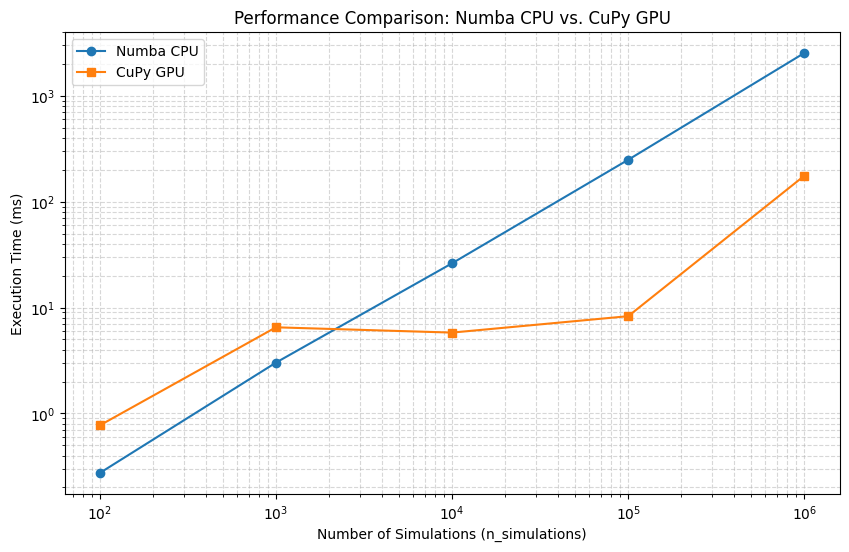

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Plot CPU and GPU times
plt.plot(n_sim_values, cpu_times, marker='o', label='Numba CPU')
plt.plot(n_sim_values, gpu_times, marker='s', label='CuPy GPU')

# Set log-log scales
plt.xscale('log')
plt.yscale('log')

# Add labels and title
plt.xlabel('Number of Simulations (n_simulations)')
plt.ylabel('Execution Time (ms)')
plt.title('Performance Comparison: Numba CPU vs. CuPy GPU')

# Add legend and grid
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)

plt.show()

**(c)** Suppose you need to run a very large simulation with `n_simulations = 100_000_000` but your GPU only has 8GB of memory. The naive CuPy implementation would require generating a matrix of shape `(n_simulations, n)` which may not fit in memory. Write a batched version that processes the simulations in chunks to stay within memory limits.

In [25]:
import cupy as cp
import numpy as np

def estimate_prob_cupy_batched(n, t, n_simulations, batch_size=1_000_000):
    """Estimate P(max of n normals > t) using CuPy with batching."""
    total_successes = 0

    # Iterate through simulations in batches
    for i in range(0, n_simulations, batch_size):
        # Handle the last batch which might be smaller than batch_size
        current_batch_size = min(batch_size, n_simulations - i)

        # Generate samples for this batch directly on GPU
        data = cp.random.randn(current_batch_size, n)

        # Find max along each trial and count exceedances
        max_vals = cp.max(data, axis=1)
        total_successes += cp.sum(max_vals > t)

        # Free memory (optional but good practice for large batches)
        del data
        del max_vals

    return float(total_successes / n_simulations)

# Test with a large simulation size to verify memory handling
n_test = 100
t_test = 2.0
n_sims_test = 10_000_000

print(f"Running batched simulation for {n_sims_test:,} trials...")
prob = estimate_prob_cupy_batched(n_test, t_test, n_sims_test)
print(f"Estimated Probability: {prob:.6f}")

Running batched simulation for 10,000,000 trials...
Estimated Probability: 0.899672
